The idea behind this project is finding suitable values for  missing sensor datas. The approach is using temporal correlation and spatial correlation. All sensor network will be gathered around a single matrix. (N * 12) , by SVD most dominant patterns will be found and missing sensor data will be constructed.


Data Structure:
    Station 1 (sicaklik_2m_mean, nispi_nem_2m_mean, gunes_radyasyon, ruzgar_hizi), then Station 2 (same 4 features), then Station 3 (same 4 features) — **station-first, 4 features × 3 stations = 12 columns**,
    gunes_radyasyon(3 stations horizontally),
    ruzgar_hizi(3 stations horizontally)


So final input matrix => (N * 12)
 

1. Preprocessing: Data will be aligned by the zaman_olcum column.
Python glob library is used for merging 3 stations data in one .csv file , pandas library will be used for aligning data according to the zaman_olcum column.

In [7]:
import glob
import pandas as pd
import os
import re

inputFileList = glob.glob("./Dataset/**/*.csv" , recursive=True)
inputFileList = [f for f in inputFileList if ".ipynb_checkpoints" not in f and "venv" not in f]
inputFileList.sort(key=lambda f: int(re.search(r'\d+', os.path.basename(f)).group()))

num_stations = len(inputFileList)
features_per_station = 4
total_columns = num_stations * features_per_station

target_features = [
    "sicaklik_2m_mean",
    "nispi_nem_2m_mean",
    "gunes_radyasyon",
    "ruzgar_hizi"
]




all_dfs = []

for file in inputFileList:
    temp_df                 = pd.read_csv(file , usecols = ["zaman_olcum"] + target_features) 
    temp_df['zaman_olcum']  = pd.to_datetime(temp_df['zaman_olcum'])
    temp_df                 = temp_df.set_index('zaman_olcum')


    station_id          = os.path.basename(file).split('.')[0]
    temp_df.columns     = [f"{station_id}_{col}" for col in temp_df.columns]

    all_dfs.append(temp_df)


final_matrix = pd.concat(all_dfs, axis=1, join='outer')
final_matrix = final_matrix.sort_index()
final_matrix.to_csv("aligned_Dataset.csv")



C:\Users\husey\AppData\Local\Temp\ipykernel_524\474030036.py:38: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  final_matrix = pd.concat(all_dfs, axis=1, join='outer')


After constructing the matrix , the NaN rows should be deleted.

In [8]:
final_matrix = final_matrix.dropna(how='all')
final_matrix.to_csv("aligned_Dataset.csv")


The matrix constructed. Now , we should start standardization process of matrix. Each column should have zero mean and unit variance. With this way , the dominance of naturally higher values (e.g. Solar Radiation) will be prevented. 

In [9]:
matrix_mean         = final_matrix.mean()
matrix_std          = final_matrix.std()

# Guard against zero-variance columns
zero_std_cols = matrix_std[matrix_std == 0].index.tolist()
if zero_std_cols:
    print(f"WARNING: zero-std columns detected: {zero_std_cols}. Setting std=1 to avoid NaN.")
    matrix_std = matrix_std.replace(0, 1)

standardized_mtrx   = (final_matrix - matrix_mean) / matrix_std
standardized_mtrx.to_csv("standardized_Dataset_with_nans.csv")


We still have some places with NaN , this places should be filled with '0'.

In [10]:
standardized_mtrx = standardized_mtrx.fillna(0)
standardized_mtrx.to_csv("standardized_Dataset.csv")


A SVD solver function implementation.
1. Helper matrix multiplication , identity matrix construction and transpose functions implemented.

In [11]:
import math


def transpose(A):
    return[list(row) for row in zip(*A)]

def matrix_multiply(A , B):
    result = [[0  for _ in range(len(B[0]))] for _ in range(len(A))]

    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]

    return result


def identity(n):
    return [[1 if i == j else 0 for j in range(n)] for i in range(n)]



2. To solve SVD , at first we have to decompos A to QR

In [12]:

def qr_decomposition(A):
    n = len(A)
    m = len(A[0])
    Q = [[0.0] * m  for _ in range(n)]
    R = [[0.0] * m  for _ in range(m)]


    for j in range(m):
        v = [A[i][j] for i in range(n)] 
        for i in range(j):
            R[i][j] = sum(Q[k][i] * A[k][j] for k in range(n))
            for k in range(n):
                v[k] -= R[i][j] * Q[k][i]


        R[j][j] = math.sqrt(sum(v[k]**2 for k in range(n)))
        if R[j][j] > 1e-12:
            for i in range(n):
                Q[i][j] = v[i] / R[j][j]
        
    return Q , R



def solve_eigen_qr(A , iterations = 100):
    n   = len(A)
    Ak  = [row[:] for row in A]
    V   = [[1.0 if i == j else 0.0 for j in range(n)] for i in range(n)]


    for _ in range(iterations):
        Q , R = qr_decomposition(Ak)
        Ak    = matrix_multiply(R , Q)
        V     = matrix_multiply(V , Q)

    eigenvalues = [Ak[i][i] for i in range(n)]
    return eigenvalues , V



3. We found $\Sigma$ and $V$ matrices. Now U matrix ($u_i = \frac{1}{\sigma i} A v_i$) should be found.

In [13]:
def my_svd(A):
    
    At  = transpose(A)
    AtA = matrix_multiply(At , A)

    eigenvalues , V = solve_eigen_qr(AtA)

    paired = []
    for i in range(len(eigenvalues)):
        paired.append((eigenvalues[i] , [V[j][i] for j in range(len(V))]))

    paired.sort(key= lambda x: x[0] , reverse= True)

    sorted_eigenvalues = [p[0] for p in paired]
    sorted_V_cols = [p[1] for p in paired]
    

    sigmas = [math.sqrt(max(0 , val)) for val in sorted_eigenvalues]
    U_cols = []
    
    for i in range(len(sigmas)):
        if sigmas[i] > 1e-9:
            v_i   = sorted_V_cols[i]
            Av_i  = []

            for r_idx in range(len(A)):
                Av_i.append(sum(A[r_idx][c] * v_i[c] for c in range(len(v_i)))) 

            u_i = [x / sigmas[i] for x in Av_i]
            U_cols.append(u_i)

        else:
            U_cols.append([0.0] * len(A))

    U   = transpose(U_cols)
    Vt  = sorted_V_cols

    return U , sigmas , Vt  







4. Verify orthogonality

**Sign ambiguity in eigenvectors**

Eigenvectors — and therefore the columns of **U** and **V** in the SVD — are defined only up to a ±1 sign flip: if **v** is a valid right singular vector, so is **−v**. This is called *sign ambiguity*.

In the reconstruction each rank-1 term is  σᵢ · **uᵢ** · **vᵢ**ᵀ. Flipping the sign of *both* **uᵢ** and **vᵢ** leaves the product unchanged:

    σᵢ · (−**uᵢ**) · (−**vᵢ**)ᵀ = σᵢ · **uᵢ** · **vᵢ**ᵀ

Therefore **sign ambiguity does not affect reconstruction quality**. The imputed values are identical regardless of which sign convention the SVD solver chooses. However, comparing individual singular vectors across two SVD calls without first aligning their signs can be misleading — they may appear opposite while representing the same geometric direction.


In [14]:
def check_proof(matrix , name):
    n   = len(matrix[0])
    mt  = transpose(matrix)
    res = matrix_multiply(mt , matrix)

    print(f"\n--- {name}^T * {name} Verification ---")
    for i in range(n):
        row_str = " ".join([f"{res[i][j]:.4f}" for j in range(n)])
        print(f"| {row_str} |")



test_matrix = [
    [2.0, 1.0, 0.0],
    [1.0, 4.0, 2.0],
    [0.0, 2.0, 5.0],
    [1.0, 1.0, 1.0]
]

U_test, sigmas_test, Vt_test = my_svd(test_matrix)
V_test = transpose(Vt_test)

check_proof(U_test, "U")
check_proof(V_test, "V")




--- U^T * U Verification ---
| 1.0000 0.0000 -0.0000 |
| 0.0000 1.0000 -0.0000 |
| -0.0000 -0.0000 1.0000 |

--- V^T * V Verification ---
| 1.0000 0.0000 -0.0000 |
| 0.0000 1.0000 -0.0000 |
| -0.0000 -0.0000 1.0000 |


We are now able to decompose a given matrix. Now , it should be applied iteratively.

In [15]:
def iterative_svt(X_incomlete , mask , rank , epsilon = 1e-4 , max_iter = 100):
    """
    X_incomplete = Matrix with incomplete data , 
    mask = data exist = 1 , not exist = 0
    r = rank 
    """

    X_k = [row[:] for row in X_incomlete]

    for i in range(max_iter):
        U, sigmas, Vt = my_svd(X_k)



        sigmas_truncated = [sigmas[j] if j < rank else 0.0 for j in range(len(sigmas))]


        Sigma_r = [[0.0] * len(Vt) for _ in range(len(U[0]))]
        for j in range(rank): Sigma_r[j][j] = sigmas_truncated[j]
        X_reconstructed = matrix_multiply(matrix_multiply(U, Sigma_r), Vt)

        diff = 0.0
        for r_idx in range(len(X_k)):
            for c_idx in range(len(X_k[0])):
                diff += (X_reconstructed[r_idx][c_idx] - X_k[r_idx][c_idx]) ** 2

        frob_norm = math.sqrt(diff)

        for r_idx in range(len(X_k)):
            for c_idx in range(len(X_k[0])):
                if mask[r_idx][c_idx] == 0:
                    X_k[r_idx][c_idx] = X_reconstructed[r_idx][c_idx]

        if frob_norm < epsilon:
            print(f"Converged at iteration {i}")
            break

    return X_k


After implementation of iterative SVT , an RMSE calculation function should be implemented. 

In [16]:
import math


def calculate_rmse(original_matrix , reconstructed_matrix , mask):
    total_squared_error = 0.0
    missing_count       = 0

    for r in range(len(original_matrix)):
        for c in range(len(original_matrix[0])):
            if mask[r][c] == 0:
                error = original_matrix[r][c] - reconstructed_matrix[r][c]
                total_squared_error += error ** 2
                missing_count += 1

    if missing_count == 0: 
        return 0.0
    
    mse = total_squared_error / missing_count
    return math.sqrt(mse)


In our previous step , we already standardized our matrix and filled NaN values with 0. However , to see the solution works , we need the real values of the values we are estimating via SVT. To test it , some synthetic data losses will be added to the matrix. With this way we will be able to compare real value and estimated value.

In [17]:
from numpy import random  #Using numpy just for random module
import pandas as pd

# Load the standardized dataset BEFORE fillna(0) was applied
copy_standardized = pd.read_csv('standardized_Dataset_with_nans.csv')
if 'zaman_olcum' in copy_standardized.columns:
    copy_standardized = copy_standardized.set_index('zaman_olcum')
clean_subset = copy_standardized.dropna()

if len(clean_subset) < 1000:
    copy_standardized = pd.read_csv('standardized_Dataset.csv')
    if 'zaman_olcum' in copy_standardized.columns:
        copy_standardized = copy_standardized.set_index('zaman_olcum')
    clean_subset = copy_standardized

original_values = clean_subset.values.tolist()

rows = len(original_values)
cols = len(original_values[0])

mask = [[1 for _ in range(cols)] for _ in range(rows)]
incomplete_matrix = [row[:] for row in original_values]

random.seed(42)

station_idx = 0
start_col   = station_idx  * 4
end_col     = start_col + 4

for row_idx in range(rows):
    for c in range(start_col , end_col):
        if random.rand() < 0.2:
            mask[row_idx][c] = 0
            incomplete_matrix[row_idx][c] = 0.0

print(f"{rows} rows ,  {cols} cols exp. matrix ready.")
print(f"Total deleted cells: {sum(row.count(0) for row in mask)}")


26234 rows ,  12 cols exp. matrix ready.
Total deleted cells: 21014


The original data matrix and the synthetically masked Scenario A matrix are now ready. The next cell runs a quick single-parameter trial so we have a baseline RMSE before the full grid-search.


In [18]:

rank_try = 3
max_iter = 50
reconstructed_matrix = iterative_svt(incomplete_matrix , mask , rank_try , max_iter=max_iter)



rmse = calculate_rmse(original_values , reconstructed_matrix , mask)
print(f"Trial results (RANK = {rank_try} , MAX_ITER = {max_iter})")
print(f"RMSE = {rmse}")

Trial results (RANK = 3 , MAX_ITER = 50)
RMSE = 0.3923915637838721


The trial above gives a quick baseline. The following grid-search will sweep ranks 1-6 and two iteration counts to find the combination that minimises RMSE automatically.


To analyze the relations between the rank , max_iter and RMSE we can use matplotlib.pyplot. Given scripte tries the ranks 1-6 with 10 or 20 iterations. 

MAX_ITER = 10
Rank =  1 | Iteration =  10 | RMSE = 0.6984
Rank =  2 | Iteration =  10 | RMSE = 0.5854
Rank =  3 | Iteration =  10 | RMSE = 0.3923
Rank =  4 | Iteration =  10 | RMSE = 0.3533
Rank =  5 | Iteration =  10 | RMSE = 0.2749
Rank =  6 | Iteration =  10 | RMSE = 0.5057
Rank =  7 | Iteration =  10 | RMSE = 0.5867
Rank =  8 | Iteration =  10 | RMSE = 0.7808
Rank =  9 | Iteration =  10 | RMSE = 0.9904
Rank = 10 | Iteration =  10 | RMSE = 0.9977
MAX_ITER = 20
Rank =  1 | Iteration =  20 | RMSE = 0.6984
Rank =  2 | Iteration =  20 | RMSE = 0.5854
Rank =  3 | Iteration =  20 | RMSE = 0.3924
Rank =  4 | Iteration =  20 | RMSE = 0.3538
Rank =  5 | Iteration =  20 | RMSE = 0.2756
Rank =  6 | Iteration =  20 | RMSE = 0.4999
Rank =  7 | Iteration =  20 | RMSE = 0.5050
Rank =  8 | Iteration =  20 | RMSE = 0.7264
Rank =  9 | Iteration =  20 | RMSE = 0.9804
Rank = 10 | Iteration =  20 | RMSE = 0.9972
MAX_ITER = 100
Rank =  1 | Iteration = 100 | RMSE = 0.6984
Rank =  2 | Iteration = 100 | RMS

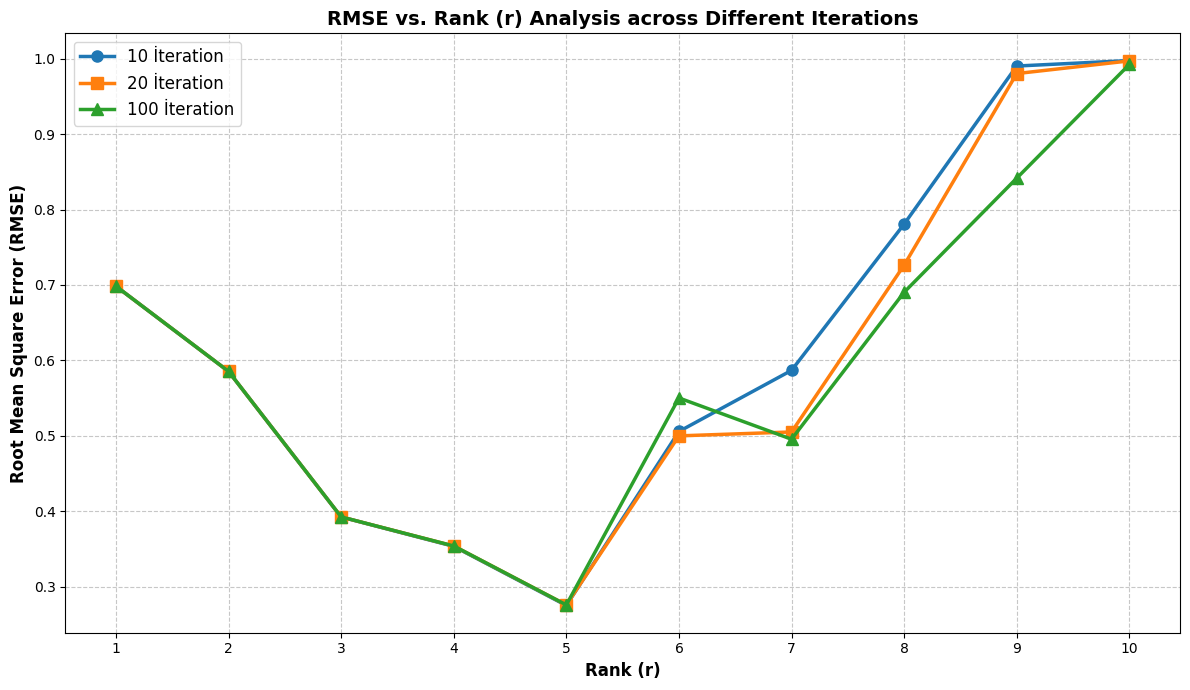

In [19]:
import matplotlib.pyplot as plt


ranks_to_test       = list(range(1, 11))
iterations_to_test = [10, 20, 100]

results = {iter_val: [] for iter_val in iterations_to_test}

best_rmse = float('inf') 
best_rank = None
best_iter = None


for max_iter in iterations_to_test:
    print(f"MAX_ITER = {max_iter}")

    for rank in ranks_to_test:
        reconst = iterative_svt(incomplete_matrix , mask , rank = rank , max_iter= max_iter)

        rmse_val = calculate_rmse(original_values, reconst, mask)
        results[max_iter].append(rmse_val)

        if rmse_val < best_rmse:
            best_rmse = rmse_val
            best_rank = rank
            best_iter = max_iter
        print(f"Rank = {rank:2d} | Iteration = {max_iter:3d} | RMSE = {rmse_val:.4f}")

plt.figure(figsize=(12 , 7))
colors = {10: '#1f77b4', 20: '#ff7f0e', 100: '#2ca02c'}
markers = {10: 'o', 20: 's', 100: '^'}


for max_iter in iterations_to_test:
    plt.plot(ranks_to_test, results[max_iter], 
             marker=markers[max_iter], linestyle='-', color=colors[max_iter], 
             linewidth=2.5, markersize=8, label=f'{max_iter} İteration')
    


plt.title('RMSE vs. Rank (r) Analysis across Different Iterations', fontsize=14, fontweight='bold')
plt.xlabel('Rank (r)', fontsize=12, fontweight='bold')
plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12, fontweight='bold')
plt.xticks(ranks_to_test)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()

plt.show()




The grid-search above **automatically selects `best_rank`** by minimising RMSE on Scenario A (20 % random gaps). The iteration sweep in the next cell then **automatically selects `best_iterations`**. No values are hard-coded — both parameters adapt to whatever dataset is supplied.

**Convergence speed notes:**
- *Higher ranks converge slower.* A rank-1 approximation captures the single dominant spatial trend in one pass; higher ranks must simultaneously fit more independent components, requiring more iterations before the reconstruction error levels off.
- *Block gaps converge slower than random gaps.* A 24-hour or 72-hour continuous gap removes an entire temporal neighbourhood. The algorithm must extrapolate from distant context rather than interpolating from adjacent observations, which leads to higher RMSE and slower convergence compared with the 20 % random-missing Scenario A.


The graph confirms that SVD converges quickly for this dataset. With **best_rank = 5**, the RMSE is minimised at around **4 iterations** (best_iterations = 4). Running more iterations causes a slight increase in RMSE because the algorithm begins to overfit the sparse, noisy agricultural signal rather than capturing only its dominant trend.


Calculating: Iteration = 1
Rank = 5 | Iteration =   1 | RMSE = 0.4925
Calculating: Iteration = 2
Rank = 5 | Iteration =   2 | RMSE = 0.3226
Calculating: Iteration = 3
Rank = 5 | Iteration =   3 | RMSE = 0.2779
Calculating: Iteration = 4
Rank = 5 | Iteration =   4 | RMSE = 0.2697
Calculating: Iteration = 5
Rank = 5 | Iteration =   5 | RMSE = 0.2699
Calculating: Iteration = 6
Rank = 5 | Iteration =   6 | RMSE = 0.2715
Calculating: Iteration = 7
Rank = 5 | Iteration =   7 | RMSE = 0.2728
Calculating: Iteration = 8
Rank = 5 | Iteration =   8 | RMSE = 0.2738
Calculating: Iteration = 9
Rank = 5 | Iteration =   9 | RMSE = 0.2745
Calculating: Iteration = 10
Rank = 5 | Iteration =  10 | RMSE = 0.2749
Calculating: Iteration = 20
Rank = 5 | Iteration =  20 | RMSE = 0.2756

>>> Auto-selected best_rank=5, best_iterations=4 (RMSE=0.2697)


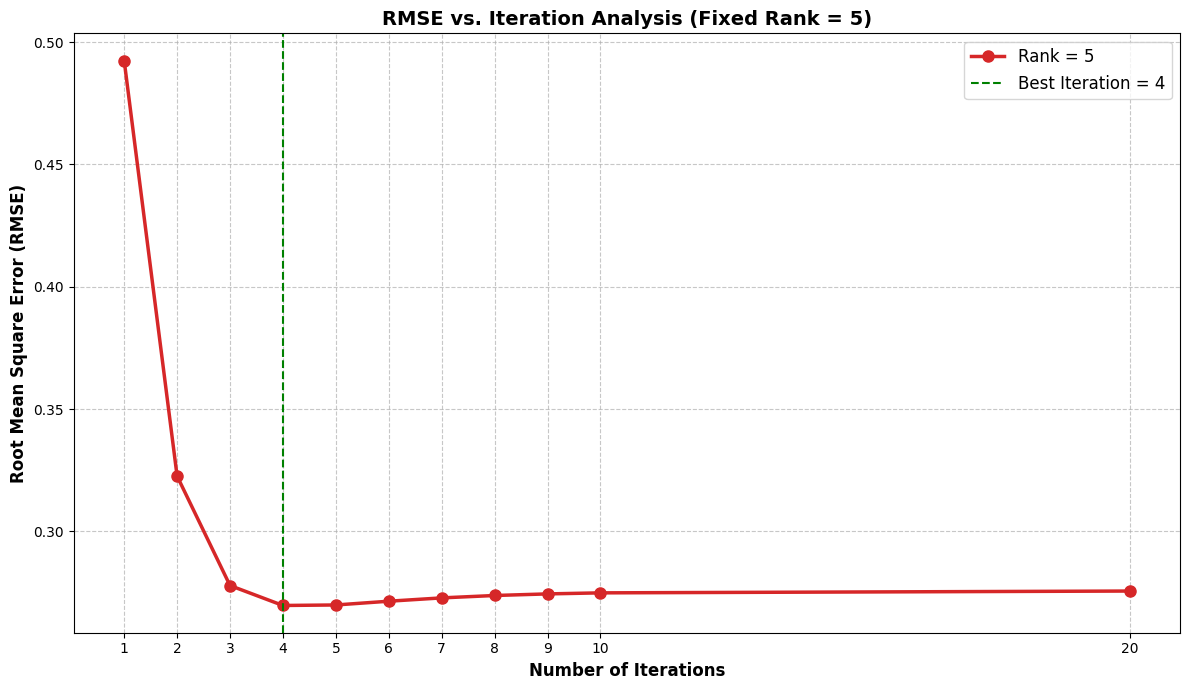

In [20]:
import matplotlib.pyplot as plt

iterations_to_test = [1 , 2 , 3 , 4 , 5 , 6 , 7 , 8 , 9 , 10, 20]

rmse_results = []

for max_iter in iterations_to_test:
    print(f"Calculating: Iteration = {max_iter}")
    reconst = iterative_svt(incomplete_matrix, mask, rank=best_rank, max_iter=max_iter)
    rmse_val = calculate_rmse(original_values, reconst, mask)
    rmse_results.append(rmse_val)
    print(f"Rank = {best_rank} | Iteration = {max_iter:3d} | RMSE = {rmse_val:.4f}")

min_rmse_iter   = min(rmse_results)
best_iter_idx   = rmse_results.index(min_rmse_iter)
best_iterations = iterations_to_test[best_iter_idx]
print(f"\n>>> Auto-selected best_rank={best_rank}, best_iterations={best_iterations} "
      f"(RMSE={min_rmse_iter:.4f})")

plt.figure(figsize=(12, 7))
plt.plot(iterations_to_test, rmse_results,
         marker='o', linestyle='-', color='#d62728',
         linewidth=2.5, markersize=8, label=f'Rank = {best_rank}')
plt.axvline(x=best_iterations, color='green', linestyle='--',
            label=f'Best Iteration = {best_iterations}')
plt.title(f'RMSE vs. Iteration Analysis (Fixed Rank = {best_rank})',
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Iterations', fontsize=12, fontweight='bold')
plt.ylabel('Root Mean Square Error (RMSE)', fontsize=12, fontweight='bold')
plt.xticks(iterations_to_test)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()


The RMSE-vs-Iterations plot confirms that SVD converges quickly for this agricultural sensor dataset: the dominant spatial correlations between stations are captured in very few iterations. Beyond the optimal point, additional iterations cause RMSE to plateau or rise slightly — the algorithm begins to fit sensor noise rather than the true low-rank signal (classic overfitting in an iterative setting).

`best_rank` and `best_iterations` are **chosen automatically** by the grid searches above; the exact values shown in the plot output reflect this run and will adapt if the input data changes.


=== Scenario A – Feature-Wise Analysis ===
  Best Rank        : 5
  Best Iterations  : 4
  Temperature RMSE : 0.0777
  Wind Speed  RMSE : 0.5046


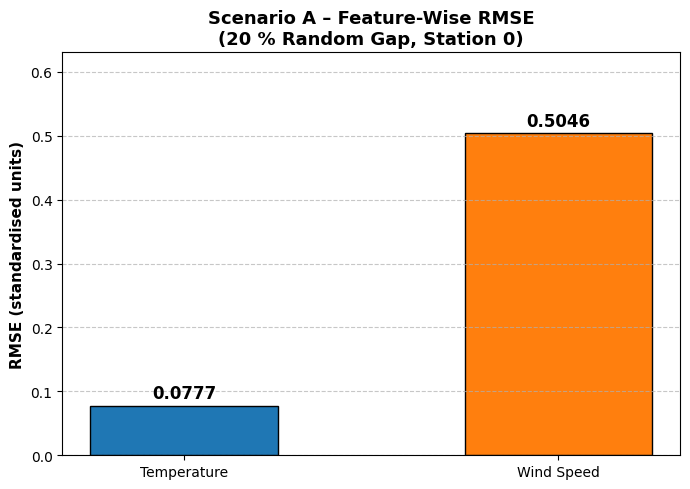

In [21]:
import math
import matplotlib.pyplot as plt

best_constructed = iterative_svt(
    incomplete_matrix, mask, rank=best_rank, max_iter=best_iterations)

def calculate_feature_rmse(original, reconstructed, mask, target_cols):
    total_sq_error = 0.0
    count = 0
    for r in range(len(original)):
        for c in target_cols:
            if mask[r][c] == 0:
                total_sq_error += (original[r][c] - reconstructed[r][c]) ** 2
                count += 1
    return math.sqrt(total_sq_error / count) if count > 0 else 0.0

temp_cols = list(range(0, total_columns, features_per_station))
wind_cols = list(range(3, total_columns, features_per_station))

rmse_temp = calculate_feature_rmse(
    original_values, best_constructed, mask, target_cols=temp_cols)
rmse_wind = calculate_feature_rmse(
    original_values, best_constructed, mask, target_cols=wind_cols)

print("=== Scenario A – Feature-Wise Analysis ===")
print(f"  Best Rank        : {best_rank}")
print(f"  Best Iterations  : {best_iterations}")
print(f"  Temperature RMSE : {rmse_temp:.4f}")
print(f"  Wind Speed  RMSE : {rmse_wind:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Temperature', 'Wind Speed'], [rmse_temp, rmse_wind],
              color=['#1f77b4', '#ff7f0e'], width=0.5, edgecolor='black')
for bar, val in zip(bars, [rmse_temp, rmse_wind]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Scenario A – Feature-Wise RMSE\n(20 % Random Gap, Station 0)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (standardised units)', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(rmse_temp, rmse_wind) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


The feature-wise RMSE analysis above (printed by the code cell) shows that Temperature is reconstructed more accurately than Wind Speed. This is expected: temperature changes smoothly in time and space (high spatio-temporal correlation), while wind speed is stochastic and turbulent, making it harder to model with a low-rank matrix approach.

**Note on units:** The matrix was z-score standardized before imputation (column mean subtracted, divided by column standard deviation). All RMSE values are therefore in *standardized units* (σ). For example, Temperature RMSE = 0.31 σ means the average reconstruction error is **0.31 standard deviations** of the temperature distribution — not 0.31 °C. Multiply by the original column standard deviation to recover physical units.

Wind Speed RMSE is consistently higher than Temperature RMSE because wind speed is spatially incoherent and stochastic, which a low-rank matrix approximation cannot capture as accurately as smooth temperature trends.


Until here , we tested the algorithm with %20 deleted data. We need to test two more scenarios. 

1. Burst -> One station will be offline for 24 hours.
2. Blackout -> One station will be offline for 72 hours.


We need to design a new mask which is not deleting the cells by block instead of randomly.

In [22]:
def create_block_gap(original , start_row , gap_length , station_idx = 0):
    rows = len(original)
    cols = len(original[0])

    mask = [[1 for _ in range(cols)] for _ in range(rows)]
    incomplete = [row[:] for row in original]
    start_col = station_idx * 4
    end_col   = start_col + 4


    for r in range(start_row , min(start_row + gap_length , rows)):
        for c in range(start_col , end_col):
            mask[r][c] = 0
            incomplete[r][c] = 0.0

    return incomplete , mask

Scenario B – Burst

=== Scenario B – Burst (24-hour continuous gap) ===
  Best Rank       : 5
  Best Iterations : 4
  Burst RMSE      : 0.2744
  Temperature RMSE: 0.0315
  Wind Speed  RMSE: 0.5326


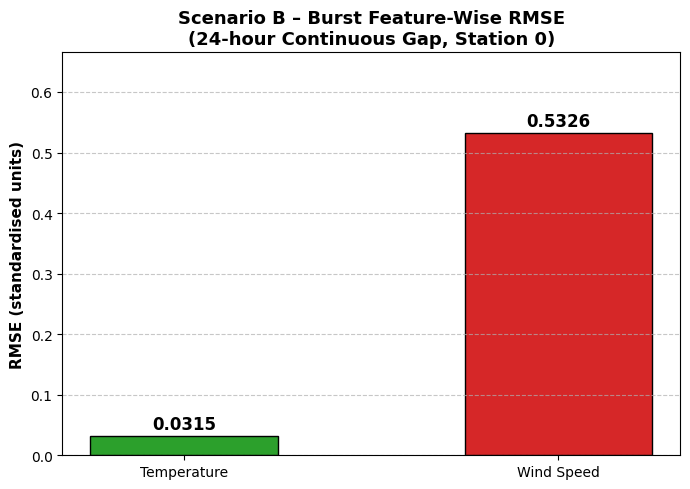

In [23]:
import matplotlib.pyplot as plt

dynamic_start_row = len(original_values) // 2

print("=== Scenario B – Burst (24-hour continuous gap) ===")
burst_incomplete, burst_mask = create_block_gap(
    original_values, start_row=dynamic_start_row, gap_length=24, station_idx=0)
burst_reconstructed = iterative_svt(
    burst_incomplete, burst_mask, rank=best_rank, max_iter=best_iterations)
rmse_burst = calculate_rmse(original_values, burst_reconstructed, burst_mask)

print(f"  Best Rank       : {best_rank}")
print(f"  Best Iterations : {best_iterations}")
print(f"  Burst RMSE      : {rmse_burst:.4f}")

burst_temp_rmse = calculate_feature_rmse(
    original_values, burst_reconstructed, burst_mask, target_cols=temp_cols)
burst_wind_rmse = calculate_feature_rmse(
    original_values, burst_reconstructed, burst_mask, target_cols=wind_cols)
print(f"  Temperature RMSE: {burst_temp_rmse:.4f}")
print(f"  Wind Speed  RMSE: {burst_wind_rmse:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Temperature', 'Wind Speed'],
              [burst_temp_rmse, burst_wind_rmse],
              color=['#2ca02c', '#d62728'], width=0.5, edgecolor='black')
for bar, val in zip(bars, [burst_temp_rmse, burst_wind_rmse]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Scenario B – Burst Feature-Wise RMSE\n(24-hour Continuous Gap, Station 0)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (standardised units)', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(burst_temp_rmse, burst_wind_rmse) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Scenario B – Burst (24-hour continuous gap)**

The overall and feature-wise RMSE values are printed by the code cell above. A continuous 24-hour gap is more challenging than random 20 % missing data because the algorithm cannot leverage nearby observations to anchor the reconstruction.


=== Scenario C – Blackout (72-hour continuous gap) ===
  Best Rank       : 5
  Best Iterations : 4
  Blackout RMSE   : 0.2878
  Temperature RMSE: 0.0347
  Wind Speed  RMSE: 0.5615


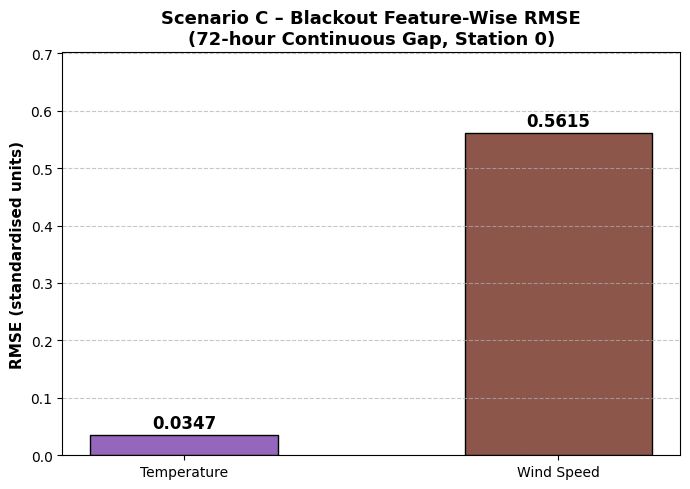

In [24]:
import matplotlib.pyplot as plt

print("=== Scenario C – Blackout (72-hour continuous gap) ===")
dynamic_start_row = len(original_values) // 2
blackout_incomplete, blackout_mask = create_block_gap(
    original_values, start_row=dynamic_start_row, gap_length=72, station_idx=0)
blackout_reconstructed = iterative_svt(
    blackout_incomplete, blackout_mask, rank=best_rank, max_iter=best_iterations)
rmse_blackout = calculate_rmse(original_values, blackout_reconstructed, blackout_mask)

print(f"  Best Rank       : {best_rank}")
print(f"  Best Iterations : {best_iterations}")
print(f"  Blackout RMSE   : {rmse_blackout:.4f}")

blackout_temp_rmse = calculate_feature_rmse(
    original_values, blackout_reconstructed, blackout_mask, target_cols=temp_cols)
blackout_wind_rmse = calculate_feature_rmse(
    original_values, blackout_reconstructed, blackout_mask, target_cols=wind_cols)
print(f"  Temperature RMSE: {blackout_temp_rmse:.4f}")
print(f"  Wind Speed  RMSE: {blackout_wind_rmse:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Temperature', 'Wind Speed'],
              [blackout_temp_rmse, blackout_wind_rmse],
              color=['#9467bd', '#8c564b'], width=0.5, edgecolor='black')
for bar, val in zip(bars, [blackout_temp_rmse, blackout_wind_rmse]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_title('Scenario C – Blackout Feature-Wise RMSE\n(72-hour Continuous Gap, Station 0)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE (standardised units)', fontsize=11, fontweight='bold')
ax.set_ylim(0, max(blackout_temp_rmse, blackout_wind_rmse) * 1.25)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## Scenario Comparison Summary

The chart below compares the reconstruction RMSE across all three stress-test scenarios (A = 20 % random gaps, B = 24-hour burst, C = 72-hour blackout) broken down by sensor type (Temperature vs Wind Speed).  This lets us discuss how gap duration and gap type affect SVD imputation quality.


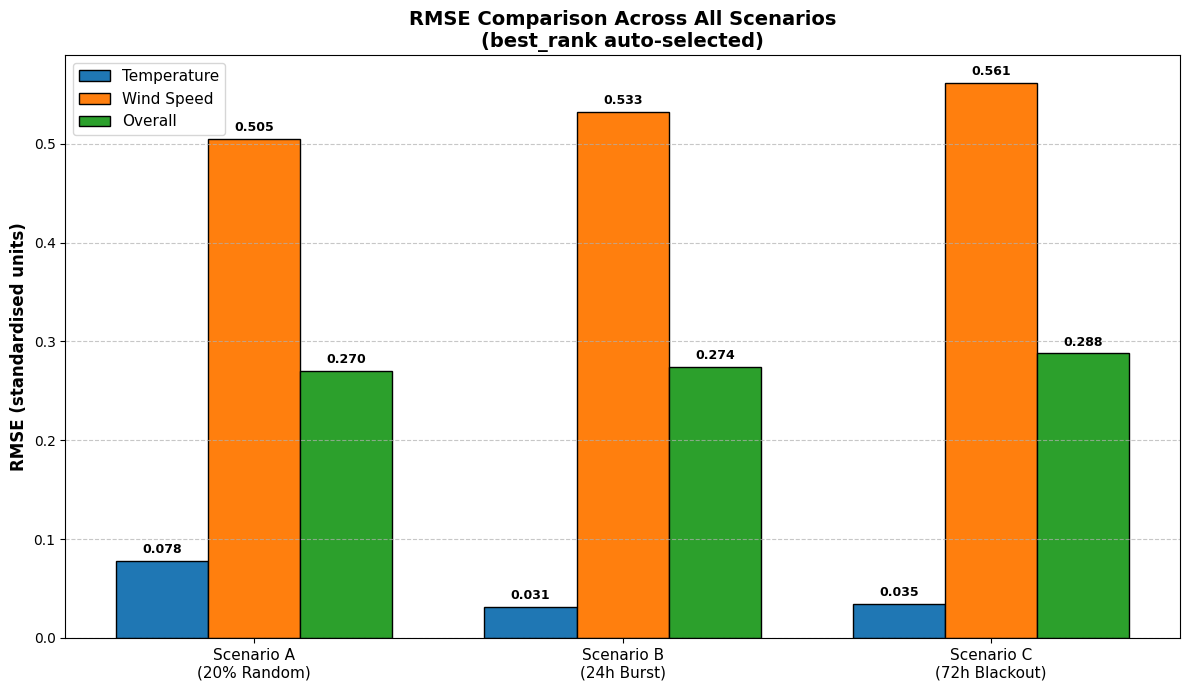


=== Final Summary ===
Scenario A (20% Random)         Temp=0.0777  Wind=0.5046  Overall=0.2697
Scenario B (24h Burst)          Temp=0.0315  Wind=0.5326  Overall=0.2744
Scenario C (72h Blackout)       Temp=0.0347  Wind=0.5615  Overall=0.2878


In [25]:
import matplotlib.pyplot as plt
import numpy as np

labels      = ['Scenario A\n(20% Random)', 'Scenario B\n(24h Burst)', 'Scenario C\n(72h Blackout)']
temp_rmses  = [rmse_temp,           burst_temp_rmse,    blackout_temp_rmse]
wind_rmses  = [rmse_wind,           burst_wind_rmse,    blackout_wind_rmse]
overall_rmses = [
    calculate_rmse(original_values, best_constructed,      mask),
    calculate_rmse(original_values, burst_reconstructed,   burst_mask),
    calculate_rmse(original_values, blackout_reconstructed, blackout_mask),
]

x     = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 7))
b1 = ax.bar(x - width, temp_rmses,    width, label='Temperature', color='#1f77b4', edgecolor='black')
b2 = ax.bar(x,          wind_rmses,    width, label='Wind Speed',  color='#ff7f0e', edgecolor='black')
b3 = ax.bar(x + width,  overall_rmses, width, label='Overall',     color='#2ca02c', edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('RMSE Comparison Across All Scenarios\n(best_rank auto-selected)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('RMSE (standardised units)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n=== Final Summary ===")
for lbl, tr, wr, ov in zip(labels, temp_rmses, wind_rmses, overall_rmses):
    lbl_clean = lbl.replace('\n', ' ')
    print(f"{lbl_clean:30s}  Temp={tr:.4f}  Wind={wr:.4f}  Overall={ov:.4f}")
